In [1]:
import os
import pandas as pd
import numpy as np
import sys
import re
import logging
from Modules.Loader_wrangler import *
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
import matplotlib.pyplot as plt

In [2]:
# Configure basic logging
logging.basicConfig(level=logging.INFO, force=True, format='%(levelname)s: %(message)s')

In [1]:
df2017 = loader(output_file_name="merged_df2017.pkl", chunksize=100000, sample_size=100000, survey_year=2017)
df2018 = loader(output_file_name="merged_df2018.pkl", chunksize=100000, sample_size=100000, survey_year=2018)
df2019 = loader(output_file_name="merged_df2019.pkl", chunksize=100000, sample_size=100000, survey_year=2019)
df2020 = loader(output_file_name="merged_df2020.pkl", chunksize=100000, sample_size=100000, survey_year=2020)
df2021 = loader(output_file_name="merged_df2021.pkl", chunksize=100000, sample_size=100000, survey_year=2021)

NameError: name 'loader' is not defined

In [3]:
nts2017 = pd.read_pickle("/home/trapfishscott/Cambridge24.25/D200_ML_econ/ProblemSets/Project/data/merged_df2017.pkl")
nts2018 = pd.read_pickle("/home/trapfishscott/Cambridge24.25/D200_ML_econ/ProblemSets/Project/data/merged_df2018.pkl")
nts2019 = pd.read_pickle("/home/trapfishscott/Cambridge24.25/D200_ML_econ/ProblemSets/Project/data/merged_df2019.pkl")
nts2020 = pd.read_pickle("/home/trapfishscott/Cambridge24.25/D200_ML_econ/ProblemSets/Project/data/merged_df2020.pkl")
nts2021 = pd.read_pickle("/home/trapfishscott/Cambridge24.25/D200_ML_econ/ProblemSets/Project/data/merged_df2021.pkl")

In [4]:
nts2017["IsTrip"] = 1
nts2018["IsTrip"] = 1
nts2019["IsTrip"] = 1
nts2020["IsTrip"] = 1
nts2021["IsTrip"] = 1

### Obtaining only relevant variables and making into a time series

## Data Manipulation pipeline

1. One-hot encode categorical features + any small cleaning steps
2. Add days of the week with no car travel
3. Make data frame into wide format
4. Convert to tensor

* Includes JourSeq gaps if trips were made by non-car inbetween

In [ ]:
### small cleaning steps and one hot encoding

In [5]:
#temporal_vars = ["TWSMonth", "TravelYear", "TravelWeekDay_B01ID"]
#individual_vars =["PSUGOR_B02ID", "IndIncome2002_B02ID", "HHoldNumChildren", "DVLALengthBand_B01ID"]

numerical_outcome_vars = ["TripStart", "TripEnd", "TripDisExSW"]
categorical_outcome_vars = ["TripPurpose_B01ID", "IsTrip"]

extra_vars = ["IndividualID_x", "JourSeq"]
features_one_hot = ["PSUGOR_B02ID"]


features_numerical = ["TravelYear", "ParkWk_B01ID", "OftHome_B01ID", "WkLift_B01ID", 'IndWkGOR_B02ID',
                     "EcoStat_B02ID", "PossHmN_B01ID", 'PDrivSt_B01ID',
                     "HHoldNumChildren", "IndIncome2002_B02ID", "DVLALengthBand_B01ID", 
                     'Age_B01ID', 
                     "DTJbLong_B01ID",
                    "DTJbMonth_B01ID",  
                    "EducN_B01ID",	
                    "HHoldEmploy_B01ID",	
                    "HHoldNumPeople",
                    "HHoldStruct_B02ID",	
                    "HRPWorkStat_B02ID",	
                    "WkMode_B01ID",	   
                    "WkPlace_B01ID",
                    "VehAnMileage"]
features_cyclical = ["TWSMonth", "TravelWeekDay_B01ID"]

features = features_one_hot + features_numerical + features_cyclical
outcomes = numerical_outcome_vars + categorical_outcome_vars

In [6]:
# Cyclical encoder

def apply_cyclical_encoding(column, type_, max_val):

    if type_ == "cos":
        return np.cos(2 * np.pi * column/ max_val)
    else:
        return np.sin(2 * np.pi * column/ max_val)


def custom_numerical_scaler(x, x_min, x_max, inverse=False):
    if not inverse:
        x_scaled = (x-x_min)/(x_max - x_min)
        return x_scaled
    else:
        x_unscaled = x*(x_max - x_min) + x_min
        return x_unscaled


standard_mms = MinMaxScaler()

def log_transformer(x, inverse=False):
    if not inverse:
        return np.log1p(x)
    else:
        return np.expm1(x)
    
# Apply one-hot to categorical
ohe = OneHotEncoder(sparse_output=False)

In [7]:
log_transformer(nts2017["TripDisExSW"].mean())

2.2375537530594634

In [8]:
missing_mapping ={
    -8: 0,
    -9: 0,
    -10: 0,
}

for k, df in {2017: nts2017, 2018: nts2018, 2019: nts2019, 2020: nts2020, 2021: nts2021}.items():
    for feature in features:
        if feature not in df.columns:
            print(f"{k}: {feature}")

            # Appending feature with na
            df[feature] = 0


ts_df2017 = nts2017[features + outcomes + extra_vars].replace(missing_mapping)
ts_df2018 = nts2018[features + outcomes + extra_vars].replace(missing_mapping)
ts_df2019 = nts2019[features + outcomes + extra_vars].replace(missing_mapping)
ts_df2020 = nts2020[features + outcomes + extra_vars].replace(missing_mapping)
ts_df2021 = nts2021[features + outcomes + extra_vars].replace(missing_mapping)

ts_df_full = pd.concat([ts_df2017, ts_df2018, ts_df2019, ts_df2020, ts_df2021])

ts_df_full = pd.concat([ts_df2017, ts_df2018, ts_df2019, ts_df2020, ts_df2021])

df_to_transform = ts_df2017.copy()

# Apply cyclical encoding to cyclical column, assuming the same categories that appear in 2017 appear elsewhere

standard_mms.fit_transform(df_to_transform[features_numerical])
ohe.fit_transform(df_to_transform[features_one_hot])

# Careful not to run twice

for col in features_one_hot:
    df_to_transform[col] = df_to_transform[col].astype(int)

df_to_transform.loc[:, "TravelWeekDay_B01ID"] = df_to_transform.loc[:, "TravelWeekDay_B01ID"].astype(int)

2018: ParkWk_B01ID
2018: WkLift_B01ID
2018: PossHmN_B01ID
2020: PSUGOR_B02ID
2020: ParkWk_B01ID
2020: WkLift_B01ID
2020: PossHmN_B01ID
2021: PSUGOR_B02ID
2021: PDrivSt_B01ID


### Imputing missing travel days

In [7]:
def impute_missing_travel_week_for_i(i_df, i_id, full_week_encoding, features=features, outcomes=outcomes):
        
    break_flag = False

    # Travel days with travel 
    included_travel_day = i_df["TravelWeekDay_B01ID"].to_list()

    # Travel days with no travel
    travel_day_no_drive = list(set(full_week_encoding) - set(included_travel_day))

    # These values will repeat for empty-travel travel days
    imputed_travel_df = pd.DataFrame({
        "TravelWeekDay_B01ID": travel_day_no_drive,
        "IndividualID_x": [i_id]*len(travel_day_no_drive),
        "JourSeq": [1]*len(travel_day_no_drive)
    })


    
    # Looping through all the columns in the original df
    for col in i_df.columns:

        # For days with no travel all outcomes vars will take 0
        if col in outcomes:
            imputed_travel_df[col] = [0]*len(travel_day_no_drive)

    
        else:
        
            if col not in extra_vars + ["TravelWeekDay_B01ID"]:
                if len(i_df[col].unique()) != 1:
                    print(f"{col} is erroneous for {i_id}")
                    print(f"Unique vals: {i_df[col].unique()}")
                    break_flag = True
                    break
                else:
                    imputed_travel_df[col] = i_df[col].unique()[0]

    if break_flag:
        print("Continuing to next individual")
        return
    

    #display(imputed_travel_df)
    #display(i_df)

    # Merging on IndividualID_x and TravelWeekDay_B01ID
    #full_df = i_df.merge(imputed_travel_df, on=["IndividualID_x", "TravelWeekDay_B01ID"], how="left")

    # Concatenating df to include empty travel days
    full_df = pd.concat([i_df, imputed_travel_df])
    #display(full_df)

    full_df = full_df.sort_values(["TravelYear", "TWSMonth", "TravelWeekDay_B01ID", "JourSeq", "TripStart", "TripEnd"])

    full_df.loc[:, "TWSMonth_cos"] = apply_cyclical_encoding(column=full_df["TWSMonth"], type_="cos", max_val=12)
    full_df.loc[:, "TWSMonth_sin"] = apply_cyclical_encoding(column=full_df["TWSMonth"], type_="sin", max_val=12)

    full_df.loc[:, "TravelWeekDay_B01ID_cos"] = apply_cyclical_encoding(column=full_df["TravelWeekDay_B01ID"], type_="cos", max_val=7)
    full_df.loc[:, "TravelWeekDay_B01ID_sin"] = apply_cyclical_encoding(column=full_df["TravelWeekDay_B01ID"], type_="sin", max_val=7)

    if full_df["TripStart"].max() > 1.5:
        full_df.loc[:,"TripStart"] = full_df["TripStart"].apply(lambda x: custom_numerical_scaler(x, x_max=60*24, x_min=0))

    if full_df["TripEnd"].max() > 1.5:
        full_df.loc[:,"TripEnd"] = full_df["TripEnd"].apply(lambda x: custom_numerical_scaler(x, x_max=60*24, x_min=0))

    full_df.loc[:,"TripDisExSW"] = full_df.loc[:,"TripDisExSW"].apply(lambda x: log_transformer(x))

    full_df.loc[:,features_numerical] = standard_mms.transform(full_df[features_numerical])

    ohe_array = ohe.transform(full_df[features_one_hot])
    ohe_df = pd.DataFrame(ohe_array, columns=ohe.get_feature_names_out(features_one_hot))

    # Reset index to avoid misalignment
    full_df.reset_index(drop=True, inplace=True)
    ohe_df.reset_index(drop=True, inplace=True)

    full_df = pd.concat([full_df, ohe_df], axis=1)

    #display(full_df)


    return full_df

### Transforming to wide

In [9]:
def transform_to_wide_for_i(i_df, max_journey_seq, seq_length = 7, outcomes=outcomes, features=features, extra_vars=extra_vars):
    df = i_df.copy()

    # Making column names based off all outcome categories

    TS_TE = []
    # TripStart TripEnd
    for TS,TE in zip(["TripStart"], ["TripEnd"]):
        for i in range(1, max_journey_seq+1):
            TS_TE.append(f"{TS}_{i}")
            TS_TE.append(f"{TE}_{i}")

    #print(TS_TE)

    expected_all = [f"{col}_{i}" for col in ["TripDisExSW", "TripPurpose_B01ID", "IsTrip"] for i in range(1, max_journey_seq+1)]

    expected_all = TS_TE + expected_all
    #print(expected_all)

    # Making column names for categorical outcomes only
    expected_categorical = [f"{col}_{i}" for col in categorical_outcome_vars for i in range(1, max_journey_seq+1)]

    # Applying max daily journeys cut off
    df = df[df["JourSeq"]<=max_journey_seq]

    # Transforming to wide
    df_wide = df.pivot(index="TravelWeekDay_B01ID",
                  columns = "JourSeq",
                  values = outcomes)
    
    df_wide.columns = [f"{col[0]}_{int(col[1])}" for col in df_wide.columns]

    for col in expected_all:
        if col not in df_wide.columns:
            df_wide[col] = 0
    
    # Ensure column order is consistent
    df_wide = df_wide[expected_all]
    
    df_wide = df_wide.fillna(0)

    df_wide.reset_index(inplace=True)

    # Dropping outcome columns
    df.drop(columns=outcomes + extra_vars, axis=1, inplace = True)
    df.drop_duplicates(subset=["TravelWeekDay_B01ID"], inplace=True)

    df_wide = df_wide.merge(df, on="TravelWeekDay_B01ID", how="left")

    top_row = df_wide.head(1).copy()

    for col in expected_all:
        top_row[col] = 0
        top_row["TravelWeekDay_B01ID"] = 0

    repeated_rows = pd.concat([top_row] * seq_length, ignore_index=True)

    df_wide = pd.concat([repeated_rows, df_wide], ignore_index=True)

    df_wide.drop(columns=features_one_hot + features_cyclical, inplace=True, axis=1)

    #df_wide.drop(columns=features_cyclical + features_one_hot, axis=1, inplace=True)

    targets_only = df_wide.drop(columns=features + extra_vars, axis=1, errors="ignore")

    targets_only = targets_only.iloc[seq_length:,:]

    targets_cont = targets_only[expected_all]
    targets_cont = targets_cont.copy()
    targets_cont.drop(columns=expected_categorical, axis=1, inplace=True)


    targets_cat = targets_only[expected_categorical]

    return df_wide, targets_cont, targets_cat

### Putting altogether for LSTM

In [10]:
def prepare_data_for_LSTM(long_df, impute_missing_travel_weeks=True, transform_to_wide=False, transform_to_tensor=False, debug=False):

    df = long_df.copy()
           

    #df = df[~df["DVLALengthBand_B01ID"].isin([-8, -10])]

    # All unique individual id's to loop over
    individual_ids = df["IndividualID_x"].unique()

    # Apply numerical encoding to numerical column
    #

    df_chunks = []

    full_week_encoding = list(range(1,8))

    if debug:
        random_index = random.randint(0, len(individual_ids))

        debug_df = df[df["IndividualID_x"] == individual_ids[random_index]]

        #display(debug_df)

        debug_df = impute_missing_travel_week_for_i(debug_df, i_id=individual_ids[random_index], full_week_encoding=full_week_encoding)

        #display(debug_df)

        debug_df, debug_targets_cont, debug_targets_cat = transform_to_wide_for_i(debug_df, max_journey_seq=10)

        
        for i, col in enumerate(debug_df.columns):
            print(f"{i}: {col}")
        print("")
        '''
        for i, col in enumerate(debug_targets_cont.columns):
            print(f"{i}: {col}")
        print("")
        for i, col in enumerate(debug_targets_cat.columns):
            print(f"{i}: {col}")'
        '''

        #print(debug_df.iloc[:,[0,1,2,3,20,31]].to_latex())

        #display(debug_df.iloc[0:7,[0,1,2,46]])

        display(debug_df)

        display(debug_targets_cont)

        display(debug_targets_cat)

        return
    
    if transform_to_tensor:
        individual_tensors = []
        target_cont_tensors = []
        target_cat_tensors = []
    
    if impute_missing_travel_weeks:

        for i, individual_id in enumerate(individual_ids[:]):

            i_df = df[df["IndividualID_x"] == individual_id]

            full_df = impute_missing_travel_week_for_i(i_df, i_id=individual_id, full_week_encoding=full_week_encoding)

            #display(full_df)

            if full_df is not None:
                if not transform_to_wide:
                    df_chunks.append(full_df)

                else:

                    full_df, targets_cont, targets_cat = transform_to_wide_for_i(full_df, max_journey_seq=10)

                    print(f"{full_df.shape}, {targets_cont.shape}, {targets_cat.shape}")
                    
                    if transform_to_tensor:

                        if full_df.shape[0] == 14 and targets_cont.shape[0] == 7 and targets_cat.shape[0] == 7:
                            full_arr = full_df.to_numpy()
                            full_arr = np.expand_dims(full_arr, axis=1)

                            targets_cont_arr = targets_cont.to_numpy()
                            targets_cat_arr = targets_cat.to_numpy()

                            full_i_tensor = torch.tensor(full_arr)
                            target_cont_i_tensor = torch.tensor(targets_cont_arr)
                            target_cat_i_tensor = torch.tensor(targets_cat_arr)

                            individual_tensors.append(full_i_tensor)
                            target_cont_tensors.append(target_cont_i_tensor)
                            target_cat_tensors.append(target_cat_i_tensor)


                    else:

                        #display(full_df)
                        print("")
                        #display(targets)
                        df_chunks.append(full_df)

            sys.stdout.write(f"\rIndividual {i+1} out of {len(individual_ids)} Complete!    ")
            sys.stdout.flush()

        if transform_to_tensor:
            individual_tensors = torch.stack(individual_tensors, dim=0)
            target_cont_tensors = torch.stack(target_cont_tensors, dim=0)
            target_cat_tensors = torch.stack(target_cat_tensors, dim=0)
            return individual_tensors, target_cont_tensors, target_cat_tensors
        
        else:

            df_to_return = pd.concat(df_chunks)

            return df_to_return



    else:
        return df


In [15]:
df = prepare_data_for_LSTM(long_df=ts_df2017, debug=True)


0: TripStart_1
1: TripEnd_1
2: TripStart_2
3: TripEnd_2
4: TripStart_3
5: TripEnd_3
6: TripStart_4
7: TripEnd_4
8: TripStart_5
9: TripEnd_5
10: TripStart_6
11: TripEnd_6
12: TripStart_7
13: TripEnd_7
14: TripStart_8
15: TripEnd_8
16: TripStart_9
17: TripEnd_9
18: TripStart_10
19: TripEnd_10
20: TripDisExSW_1
21: TripDisExSW_2
22: TripDisExSW_3
23: TripDisExSW_4
24: TripDisExSW_5
25: TripDisExSW_6
26: TripDisExSW_7
27: TripDisExSW_8
28: TripDisExSW_9
29: TripDisExSW_10
30: TripPurpose_B01ID_1
31: TripPurpose_B01ID_2
32: TripPurpose_B01ID_3
33: TripPurpose_B01ID_4
34: TripPurpose_B01ID_5
35: TripPurpose_B01ID_6
36: TripPurpose_B01ID_7
37: TripPurpose_B01ID_8
38: TripPurpose_B01ID_9
39: TripPurpose_B01ID_10
40: IsTrip_1
41: IsTrip_2
42: IsTrip_3
43: IsTrip_4
44: IsTrip_5
45: IsTrip_6
46: IsTrip_7
47: IsTrip_8
48: IsTrip_9
49: IsTrip_10
50: TravelYear
51: ParkWk_B01ID
52: OftHome_B01ID
53: WkLift_B01ID
54: IndWkGOR_B02ID
55: EcoStat_B02ID
56: PossHmN_B01ID
57: PDrivSt_B01ID
58: HHoldNumChi

,TripStart_1,TripEnd_1,TripStart_2,TripEnd_2,TripStart_3,TripEnd_3,TripStart_4,TripEnd_4,TripStart_5,TripEnd_5,...,TravelWeekDay_B01ID_sin,PSUGOR_B02ID_1.0,PSUGOR_B02ID_2.0,PSUGOR_B02ID_3.0,PSUGOR_B02ID_4.0,PSUGOR_B02ID_5.0,PSUGOR_B02ID_6.0,PSUGOR_B02ID_7.0,PSUGOR_B02ID_8.0,PSUGOR_B02ID_9.0
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,...,7.818315e-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,...,7.818315e-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,...,7.818315e-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,...,7.818315e-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,...,7.818315e-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,...,7.818315e-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,...,7.818315e-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
7,0.506944,0.512500,0.525694,0.531250,0.000000,0.000000,0.000000,0.000000,0,0,...,7.818315e-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
8,0.390972,0.406250,0.529167,0.542361,0.735417,0.737500,0.737500,0.739583,0,0,...,9.749279e-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
9,0.411111,0.413889,0.414583,0.418750,0.427778,0.433333,0.435417,0.438194,0,0,...,4.338837e-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


,TripStart_1,TripEnd_1,TripStart_2,TripEnd_2,TripStart_3,TripEnd_3,TripStart_4,TripEnd_4,TripStart_5,TripEnd_5,...,TripDisExSW_1,TripDisExSW_2,TripDisExSW_3,TripDisExSW_4,TripDisExSW_5,TripDisExSW_6,TripDisExSW_7,TripDisExSW_8,TripDisExSW_9,TripDisExSW_10
7,0.506944,0.512500,0.525694,0.531250,0.000000,0.000000,0.000000,0.000000,0,0,...,1.386294,1.386294,0.000000,0.000000,0,0,0,0,0,0
8,0.390972,0.406250,0.529167,0.542361,0.735417,0.737500,0.737500,0.739583,0,0,...,2.251292,2.251292,1.064711,1.064711,0,0,0,0,0,0
9,0.411111,0.413889,0.414583,0.418750,0.427778,0.433333,0.435417,0.438194,0,0,...,1.064711,1.386294,1.223775,0.955511,0,0,0,0,0,0
10,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,...,0.000000,0.000000,0.000000,0.000000,0,0,0,0,0,0
11,0.522917,0.527083,0.532639,0.537500,0.000000,0.000000,0.000000,0.000000,0,0,...,1.386294,1.386294,0.000000,0.000000,0,0,0,0,0,0
12,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,...,0.000000,0.000000,0.000000,0.000000,0,0,0,0,0,0
13,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,...,0.000000,0.000000,0.000000,0.000000,0,0,0,0,0,0


,TripPurpose_B01ID_1,TripPurpose_B01ID_2,TripPurpose_B01ID_3,TripPurpose_B01ID_4,TripPurpose_B01ID_5,TripPurpose_B01ID_6,TripPurpose_B01ID_7,TripPurpose_B01ID_8,TripPurpose_B01ID_9,TripPurpose_B01ID_10,IsTrip_1,IsTrip_2,IsTrip_3,IsTrip_4,IsTrip_5,IsTrip_6,IsTrip_7,IsTrip_8,IsTrip_9,IsTrip_10
7,5.0,5.0,0.0,0.0,0,0,0,0,0,0,1.0,1.0,0.0,0.0,0,0,0,0,0,0
8,10.0,10.0,19.0,19.0,0,0,0,0,0,0,1.0,1.0,1.0,1.0,0,0,0,0,0,0
9,19.0,9.0,9.0,9.0,0,0,0,0,0,0,1.0,1.0,1.0,1.0,0,0,0,0,0,0
10,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0,0,0,0,0,0
11,5.0,5.0,0.0,0.0,0,0,0,0,0,0,1.0,1.0,0.0,0.0,0,0,0,0,0,0
12,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0,0,0,0,0,0
13,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0,0,0,0,0,0


In [7]:
X, y_cont, y_cat = prepare_data_for_LSTM(long_df=ts_df2017, transform_to_wide=True, transform_to_tensor=True)

NameError: name 'prepare_data_for_LSTM' is not defined

### Defining tensors and params

In [17]:
# Save tensors
with open("/home/trapfishscott/Cambridge24.25/D200_ML_econ/ProblemSets/Project/tensors/tensors.pkl", "wb") as f:
    pickle.dump((X, y_cont, y_cat), f)

### Setting up tensors

In [9]:
#Load tensors
with open("/home/trapfishscott/Cambridge24.25/D200_ML_econ/ProblemSets/Project/tensors/tensors.pkl", "rb") as f:
    (X, y_cont_raw, y_cat_raw) = pickle.load(f)

# GPU?

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

X = X.to(torch.float32).to(device)

y_ts_te = X[:,7:,:,:20].to(torch.float32).to(device)
y_distance = X[:,7:,:,20:30].to(torch.float32).to(device)
y_purpouse = X[:,7:,:,30:40].to(torch.long).to(device)
y_istrip = X[:,7:,:,40:50].to(torch.float32).to(device)
y_duration = X[:,7:,:,50:60].to(torch.float32).to(device)


index = 7
print(f"X: {X.shape}")
#print(f"y_cont: {y_cont_raw.shape}")
#print(f"y_cat: {y_cat_raw.shape}")
print(f"y_istrip: {y_istrip.shape}")
print(f"y_ts_et: {y_ts_te.shape}")
print(f"y_distance: {y_distance.shape}")
#print(f"y_duration: {y_duration.shape}")
print(f"y_purpouse: {y_purpouse.shape}")
print(f"y_istrip: {y_istrip.shape}")
print("")
print(y_ts_te[index,0,:,:])
print(y_duration[index,0,:,:])
print(y_distance[index,0,:,:])
print(y_istrip[index,0,:,:])
print(y_purpouse[index,0,:,:])


y_istrip[0,:,0,:].shape

# purpouse y_purpouse = X[:,7:,:,30:40] # Need to change 30:40 to 10*24


# Removing 

cuda
X: torch.Size([6775, 14, 1, 85])
y_istrip: torch.Size([6775, 7, 1, 10])
y_ts_et: torch.Size([6775, 7, 1, 20])
y_distance: torch.Size([6775, 7, 1, 10])
y_purpouse: torch.Size([6775, 7, 1, 10])
y_istrip: torch.Size([6775, 7, 1, 10])

tensor([[0.3021, 0.3160, 0.5451, 0.5556, 0.5556, 0.5590, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000]], device='cuda:0')
tensor([[0.0000, 0.7500, 1.0000, 0.7143, 0.1818, 0.0000, 0.7500, 0.0000, 0.0000,
         0.5000]], device='cuda:0')
tensor([[1.9459, 1.9459, 0.0953, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000]], device='cuda:0')
tensor([[1., 1., 1., 0., 0., 0., 0., 0., 0., 0.]], device='cuda:0')
tensor([[ 1,  3, 23,  0,  0,  0,  0,  0,  0,  0]], device='cuda:0')


torch.Size([7, 10])

### Creating the RNN

In [10]:
# Calculating probability weights for categorical

def return_categorical_weightings(array, num_cats = 24):
    unique_vals, counts = torch.unique(array, return_counts=True)

    print(f"Unique vals: {unique_vals}")
    print(f"And their counts... {counts}")

    # 17 is missing this refers to "short walk", not relevant for our data, but will be kept for reference

    ce_weighting = torch.zeros(num_cats, dtype=torch.float32)
    
    if num_cats == 24:
        ce_weighting[17] = 0

    for val, count in zip(unique_vals, counts):
        ce_weighting[int(val)] = 1/(count/counts.sum())

    # Apply log scaling to smooth extreme weight differences
    ce_weighting = torch.log1p(ce_weighting)  

    # Normalize the weights
    ce_weighting /= ce_weighting.sum()

    print("Final CE Weights:", ce_weighting)

    ce_weighting = ce_weighting.to(device)

    return ce_weighting

ce_weighting = return_categorical_weightings(y_purpouse[:,:,:])
print("")
binary_weightings = return_categorical_weightings(y_istrip[:,:,:], num_cats=2)

Unique vals: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 18,
        19, 20, 21, 22, 23], device='cuda:0')
And their counts... tensor([376648,  19734,   4722,   1699,    343,  10319,   9438,   2123,     39,
          6232,   9276,   2532,   1052,   6142,   1460,    857,   3863,     16,
          1969,    248,   6510,   2873,   6155], device='cuda:0')
Final CE Weights: tensor([0.0067, 0.0264, 0.0378, 0.0461, 0.0592, 0.0315, 0.0322, 0.0443, 0.0770,
        0.0356, 0.0324, 0.0429, 0.0500, 0.0357, 0.0474, 0.0517, 0.0394, 0.0000,
        0.0843, 0.0449, 0.0619, 0.0352, 0.0418, 0.0357])

Unique vals: tensor([0., 1.], device='cuda:0')
And their counts... tensor([376648,  97602], device='cuda:0')
Final CE Weights: tensor([0.3155, 0.6845])


In [11]:
# Defining parameters
INPUT_SIZE = 315    # Total number of features
HIDDEN_SIZE = 9
NUM_LAYERS = 1
OUTPUT_SIZE_TS_TE = 20    # Outsize of TripStart and TripEnd
OUTPUT_SIZE_DIST = 10     # Output Size of distance
OUTPUT_SIZE_CAT = 10 # 10 outcome vars
OUTPUT_SIZE_BIN = 10 # 10 binary vars vars

NUM_CLASSES = 24

normalised_mp_minute = log_transformer(1.1667)  # *normalised minute


class RNNmodel(nn.Module):
    def __init__(self):
        super().__init__()

        # Define RNN layer

        self.rnn = nn.RNN(INPUT_SIZE, HIDDEN_SIZE, num_layers=NUM_LAYERS)

        # Output layers

        self.output_ts_te = nn.Linear(HIDDEN_SIZE, OUTPUT_SIZE_TS_TE)
        self.output_dist = nn.Linear(HIDDEN_SIZE, OUTPUT_SIZE_DIST)
        self.output_purp = nn.Linear(HIDDEN_SIZE, OUTPUT_SIZE_CAT*NUM_CLASSES)
        self.output_bin = nn.Linear(HIDDEN_SIZE, OUTPUT_SIZE_BIN)

        self.T = 1.0  # Can be used to scale categorical logits - useful for class imbalance


    def forward(self, X):

        out, hh = self.rnn(X)
        #print(f"hh_shape: {hh.shape}")

        y_ts_te_pred = self.output_ts_te(out[-1]).reshape(1,1,OUTPUT_SIZE_TS_TE)
        y_dist_pred = self.output_dist(out[-1]).reshape(1,1,OUTPUT_SIZE_DIST)
        y_purp_pred = self.output_purp(out[-1]).reshape(OUTPUT_SIZE_CAT, NUM_CLASSES)
        y_istrip_pred = self.output_bin(out[-1]).reshape(OUTPUT_SIZE_BIN)

        y_istrip_pred = y_istrip_pred.to(torch.float32)

        # Applying sgmoid to get the loss mask
        y_istrip_pred_sgmoid = F.sigmoid(y_istrip_pred)

        # Making a probabilistic rather than deterministic mask
        y_mask = torch.bernoulli(y_istrip_pred_sgmoid).unsqueeze(1)
        #y_bin_hat_sgmoid = (y_bin_hat_sgmoid > 0.5).float()
        #y_mask = y_bin_hat_sgmoid.unsqueeze(1)
        

        # Adding softplus to ensure monotonicity in start and end time
        y_ts_te_pred = torch.cumsum(   F.softplus(y_ts_te_pred), dim=2   )
        #y_ts_te_pred = F.softplus(y_ts_te_pred)

        #y_ts_te_pred = torch.clamp(y_ts_te_pred, min=0, max=1)
        y_distance_pred = F.softplus(y_dist_pred)
        


        return y_ts_te_pred, y_distance_pred, y_purp_pred, y_istrip_pred, y_mask


In [14]:
model = RNNmodel()

for a,b in model.named_parameters():
    print(a,b.shape)

rnn.weight_ih_l0 torch.Size([9, 315])
rnn.weight_hh_l0 torch.Size([9, 9])
rnn.bias_ih_l0 torch.Size([9])
rnn.bias_hh_l0 torch.Size([9])
output_ts_te.weight torch.Size([20, 9])
output_ts_te.bias torch.Size([20])
output_dist.weight torch.Size([10, 9])
output_dist.bias torch.Size([10])
output_purp.weight torch.Size([240, 9])
output_purp.bias torch.Size([240])
output_bin.weight torch.Size([10, 9])
output_bin.bias torch.Size([10])


In [15]:
# Taking one test draw

rnn_model = RNNmodel().to(device)

X0 = X[0,:,0,:].unsqueeze(1).to(torch.float32)
print(f"X1 shape: {X0.shape}")
print("")

y_ts_te_pred_1, y_distance_pred_1, y_purpouse_pred_1, y_istrip_pred_1, y_mask_1 = rnn_model.forward(X0)
y_ts_te_true_1, y_distance_true_1, y_purpouse_true_1, y_istrip_true_1 = y_ts_te[0,0,:].reshape(1,1,-1), y_distance[0,0,:].reshape(1,1,-1), y_purpouse[0,0,:], y_istrip[0,0,:]


print(f"y_ts_te_pred: {y_ts_te_pred_1.shape}")
print(f"y_distance_pred: {y_distance_pred_1.shape}")
print(f"y_purpouse_pred: {y_purpouse_pred_1.shape}")
print(f"y_bin_pred: {y_istrip_pred_1.shape}")
print(f"y_mask: {y_mask_1.shape}")

print(f"y_ts_te_pred: {y_ts_te_pred_1}")
print(f"y_distance_pred: {y_distance_pred_1}")
#print(f"y_distance_pred: {y_distance_pred_1.shape}")
#print(f"y_purpouse_pred: {y_purpouse_pred_1.shape}")
#print(f"y_bin_pred: {y_istrip_pred_1.shape}")
#print(f"y_mask: {y_mask_1.shape}")
#print("")
print(f"y_ts_te_true: {y_ts_te_true_1.shape}")
print(f"y_distance_true: {y_distance_true_1.shape}")
print(f"y_purpouse_true: {y_purpouse_true_1.shape}")
print(f"y_bin_true: {y_istrip_true_1.shape}")
print(f"y_mask: {y_mask_1.shape}")
print(f"y_ts_te_true: {y_ts_te_true_1.shape}")
print(f"y_distance_true: {y_distance_true_1.shape}")
print(f"y_purpouse_true: {y_purpouse_true_1.shape}")
print(f"y_bin_true: {y_istrip_true_1.shape}")
print(f"y_mask: {y_mask_1.shape}")
print("")
print("This new gumbel softmax thing")
gsm = F.gumbel_softmax(y_purpouse_pred_1, tau=1, hard=True)

print(gsm)

loss_cat = nn.CrossEntropyLoss()  #(y_hat, y)
loss_cont = nn.MSELoss()
loss_bin = nn.BCEWithLogitsLoss()

print(f"Categorical loss: {loss_cat(y_purpouse_pred_1, y_purpouse_true_1)}")
print(f"Continous loss: {loss_cont(y_ts_te_pred_1, y_ts_te_true_1)}")
print(f"Binary loss: {loss_bin(y_istrip_pred_1, y_istrip_true_1)}")

print("")
#print(binary)
print("")
#print(y_purpouse_pred_1)
print("Min max penalties for ts_te")
#ts_te_penalty_below_0 = - (torch.clamp(y_ts_te_pred_1, max = 0).sum())
ts_te_penalty_above_1 = torch.clamp(y_ts_te_pred_1-1, min = 0).sum()
print(f">1: {ts_te_penalty_above_1}")
print(f"ts_te_delta matrix")
ts_te_delta = y_ts_te_pred_1[:,:,1::2] - y_ts_te_pred_1[:,:,0::2]
print(ts_te_delta)
max_distance = ts_te_delta * normalised_mp_minute
print("Applying max distance")
print(max_distance)
print("Max distance penalty")
max_distance_penalty = torch.clamp(y_distance_pred_1 - max_distance, min=0).sum()
min_distance_penalty = torch.clamp(-y_distance_pred_1, min=0).sum()


X1 shape: torch.Size([14, 1, 85])



RuntimeError: input.size(-1) must be equal to input_size. Expected 315, got 85

In [ ]:
# Configure basic logging
logging.basicConfig(level=logging.INFO, force=True, format='%(levelname)s: %(message)s')


rnn_model = RNNmodel().to(device)

ce_loss = nn.CrossEntropyLoss(weight=ce_weighting, reduction="none").to(device)  #(y_hat, y)
mse_loss = nn.MSELoss(reduction="none").to(device)
bce_loss = nn.BCEWithLogitsLoss().to(device)

optimizer = torch.optim.Adam(rnn_model.parameters(), lr=0.0005)

epochs = 1
seq_length = 7
i_to_loop = 3

c1_penalty_weight = 0.05
c2_penalty_weight = 0

ts_te_loss_weight = 0.001
purpouse_loss_weight = 4
distance_loss_weight = 0.001
istrip_loss_weight = 4

make_travel_diaries = True
complete_travel_diaries = {}
complete_travel_diaries_dfs = []

for epochi in range(epochs):

    # Collecting losses
    purpouse_loss_for_i_1 = np.zeros(i_to_loop)
    purpouse_loss_for_i_7 = np.zeros(i_to_loop)
    
    ts_te_loss_for_i_1 = np.zeros(i_to_loop)
    #tripstart_loss_for_i_7 = np.zeros(i_to_loop)

    ts_te_loss_for_i_7 = np.zeros(i_to_loop)
    #tripend_loss_for_i_7 = np.zeros(i_to_loop)

    distance_loss_for_i_1 = np.zeros(i_to_loop)
    distance_loss_for_i_7 = np.zeros(i_to_loop)

    istrip_loss_for_i_1 = np.zeros(i_to_loop)
    istrip_loss_for_i_7 = np.zeros(i_to_loop)

    total_loss_1 = np.zeros(i_to_loop)
    total_loss_7 = np.zeros(i_to_loop)


    #print(epochi)
    for individual_i in range(i_to_loop):
        #print(f"Individual: {individual_i}")

        travel_diary = X[individual_i, :, 0, :].unsqueeze(1).to(torch.float32)
        logging.debug(travel_diary.shape)

        features_constant_a = X[individual_i, :, 0, 74:].unsqueeze(1).to(torch.float32)
        features_constant_b = X[individual_i, :, 0, 76:].unsqueeze(1).to(torch.float32)
        features_time = X[individual_i, 7:, 0, 74:75].unsqueeze(1).to(torch.float32)
        
        features = X[individual_i, :, 0, 50:].unsqueeze(1).to(torch.float32)

        travel_diary7 = X[individual_i, :7, 0, :].unsqueeze(1).to(torch.float32)

        logging.debug(f"Shape of travel diary: {travel_diary.shape}")

        for i in range(0, travel_diary.shape[0] - seq_length):

            # Conditions of violation

            logging.debug(f"Indexing travel diary from {i} until {seq_length+i}")


            

            sliding_input = travel_diary[i:seq_length+i,0,:].unsqueeze(1)
            logging.debug(f"Sliding input shape: {sliding_input.shape}")
            sliding_input7 = travel_diary7[i:seq_length+i,0,:].unsqueeze(1)


            #masked_outcome_rows = travel_diary[:7,0,:30].unsqueeze(1)
            #logging.debug(masked_outcome_rows.shape) 
            #feature_rows = travel_diary[:,0,30:].unsqueeze(1)
            #logging.debug(feature_rows.shape)

            #print(sliding_input.shape)

            ## 1-AHEAD PREDICTIONS ##

            y_ts_te_pred_1, y_distance_pred_1, y_purpouse_pred_1, y_istrip_pred_1, y_mask_1 = rnn_model.forward(sliding_input)
            
            categorical_prediction = torch.argmax(y_purpouse_pred_1, dim=-1)
            #categorical_prediction = F.gumbel_softmax(y_purpouse_pred_1, tau=1.0, hard=True)
            logging.info(categorical_prediction.shape)

            y_ts_te_true, y_distance_true, y_purpouse_true, y_istrip_true = y_ts_te[individual_i,i,:].reshape(1,1,-1), y_distance[individual_i,i,:].reshape(1,1,-1), y_purpouse[individual_i,i,:].reshape(-1), y_istrip[individual_i,i,:].reshape(-1)

            ## 7-AHEAD_PREDICTIONS ##

            y_ts_te_pred_7, y_distance_pred_7, y_purpouse_pred_7, y_istrip_pred_7, y_mask_7 = rnn_model.forward(sliding_input7)
            categorical_prediction7 = torch.argmax(y_purpouse_pred_7, dim=-1)
            #categorical_prediction7 = F.gumbel_softmax(y_purpouse_pred_7, tau=1.0, hard=True)
            #logging.info(categorical_prediction7.shape)

            logging.debug("Predictions pre transform")
            logging.debug(y_ts_te_pred_7.shape)
            logging.debug(y_distance_pred_7.shape)
            logging.debug(categorical_prediction7.shape)

            # Apending to traveldiary_7
            outcome_pred_7 = torch.cat([y_ts_te_pred_7.reshape(1,1,-1),  
                                        y_distance_pred_7.reshape(1,1,-1),
                                        categorical_prediction7.reshape(1,1,-1),
                                        y_istrip_pred_7.reshape(1,1,-1)], dim=-1).detach()
            
            logging.debug("Predictions post transform")
            logging.debug(outcome_pred_7.shape)
            
            features_7 = features[seq_length+i,:,:].unsqueeze(1)
            logging.debug(f"Features shape: {features_7.shape}")

            outcome_features_7 = torch.cat([outcome_pred_7, features_7], dim=-1)
            logging.debug(f"Outcome+features: {outcome_features_7.shape}")

            travel_diary7 = torch.cat([travel_diary7, outcome_features_7], dim=0)
            logging.debug(f"New travel diary7 shape: {travel_diary7.shape}")

            '''
            if individual_i > i_to_loop - last_x_i:             # Want to return a travel diary
                # What is the model predicting
                #logging.info("")
                logging.info("")
                sigmoided1 = F.sigmoid(y_istrip_pred_1)
                sigmoided7 = F.sigmoid(y_istrip_pred_7)
                binary1 = (sigmoided1 > 0.5).float()
                binary7 = (sigmoided7 > 0.5).float()
                logging.info(f"Istrip1: {binary7}")
                #logging.info(f"Istrip7: {binary7}")
                logging.info(f"IsTrip true: {y_istrip_true}")
                logging.info(f"y_tripstart_pred1: {y_ts_te_pred_7}")
                #logging.info(f"y_tripstart_pred7: {y_tripstart_pred_7}")
                #logging.info(f"y_tripend_pred7: {y_tripend_pred_7}")
                logging.info(f"y_distance_pred7: {y_distance_pred_7}")
                logging.info(f"Max Distance7: {max_distance7}")
                #logging.info(f"y_distance_pred7: {y_distance_pred_7}")
                logging.info(f"categorical ground truth: {y_purpouse_true}")
                logging.info(f"categorical prediction1: {categorical_prediction7}")
                logging.info("")
                #logging.info(f"Mask1: {y_mask_1}")
                #logging.info(f"Mask7: {y_mask_7}")
                #logging.info(f"Mask1_interleave: {y_mask_1.repeat_interleave(2)}")
                #logging.info(f"Mask7_interleave: {y_mask_7.repeat_interleave(2)}")
            '''
            '''
            if make_travel_diaries:
                outcome_pred_7_complete = torch.cat([ (y_ts_te_pred_7).reshape(1,1,-1),  
                            (y_distance_pred_7).reshape(1,1,-1),
                            (categorical_prediction7).reshape(1,1,-1),
                            y_mask_7.reshape(1,1,-1)], dim=2).detach()
            
            '''   
            if make_travel_diaries:
                outcome_pred_7_complete = torch.cat([ (y_ts_te_pred_7 * y_mask_7.repeat_interleave(2)).reshape(1,1,-1),  
                            (y_distance_pred_7 * y_mask_7.reshape(-1)        ).reshape(1,1,-1),
                            (categorical_prediction7 * y_mask_7.reshape(-1)     ).reshape(1,1,-1),
                            y_mask_7.reshape(1,1,-1)], dim=2).detach()
                
                #logging.info(outcome_pred_7_complete.shape)
                
                if individual_i in complete_travel_diaries:
                    complete_travel_diaries[individual_i] = torch.cat([complete_travel_diaries[individual_i], outcome_pred_7_complete], dim=1).detach()
                else:
                    complete_travel_diaries[individual_i] = outcome_pred_7_complete


            # Compute MSE and CE loss for one-day-ahead of the week

            logging.debug(f"Original mask: {y_mask_1}")
            logging.debug(f"interleaved_mask: {y_mask_1.repeat_interleave(2)}")

            # RATIONALITY CONDITIONS

            ts_te_penalty_above_11 = torch.clamp(y_ts_te_pred_1-1, min = 0).sum()
            ts_te_penalty_above_17 = torch.clamp(y_ts_te_pred_7-1, min = 0).sum()

            ts_te_delta1 = y_ts_te_pred_1[:,:,1::2] - y_ts_te_pred_1[:,:,0::2]
            ts_te_delta7 = y_ts_te_pred_7[:,:,1::2] - y_ts_te_pred_7[:,:,0::2]

            max_distance1 = ts_te_delta1 * normalised_mp_minute
            max_distance7 = ts_te_delta7 * normalised_mp_minute

            max_distance_penalty1 = torch.clamp(y_distance_pred_1 - max_distance1, min=0).sum()
            min_distance_penalty1 = torch.clamp(-y_distance_pred_1, min=0).sum()
            total_distance_penalty1 = max_distance_penalty1 + max_distance_penalty1

            max_distance_penalty7 = torch.clamp(y_distance_pred_7 - max_distance7, min=0).sum()
            min_distance_penalty7 = torch.clamp(-y_distance_pred_7, min=0).sum()
            total_distance_penalty7 = max_distance_penalty7 + max_distance_penalty7

            ts_te_loss1 = mse_loss(y_ts_te_pred_1, y_ts_te_true)
            ts_te_loss1 = (ts_te_loss1 * y_mask_1.repeat_interleave(2)).sum() / (y_mask_1.repeat_interleave(2).sum() + 1e-6)

            #tripend_loss1 = mse_loss(y_tripend_pred_1, y_tripend_true)
            #tripend_loss1 = (tripend_loss1 * y_mask_1).sum() / (y_mask_1.sum() + 1e-6)

            distance_loss1 = mse_loss(y_distance_pred_1, y_distance_true)
            distance_loss1 = (distance_loss1 * y_mask_1).sum() / (y_mask_1.sum() + 1e-6)

            purpouse_loss1 = ce_loss(y_purpouse_pred_1, y_purpouse_true)
            purpouse_loss1 = (purpouse_loss1).sum() / (len(y_mask_1))

            istrip_loss1 = bce_loss(y_istrip_pred_1, y_istrip_true)

            logging.debug(f"y_istrip_pred_1 (logits): {y_istrip_pred_1}")
            logging.debug(f"y_istrip_true: {y_istrip_true}")
            logging.debug(f"BCE Loss: {istrip_loss1.item()}")

            combined_loss1 = ts_te_loss_weight*ts_te_loss1 + distance_loss_weight*distance_loss1 + purpouse_loss_weight*purpouse_loss1 + istrip_loss_weight*istrip_loss1 + c1_penalty_weight*ts_te_penalty_above_11 + c2_penalty_weight*max_distance_penalty1

            # Compute MSE and CE loss for one-day-ahead of the week

            logging.debug("7-day ahead grads?")
            logging.debug(f"IsTrip: {y_istrip_pred_7.requires_grad}")
            logging.debug(f"y_tripstart_pred7: {y_ts_te_pred_7.requires_grad}")
            logging.debug(f"y_distance_pred7: {y_distance_pred_7.requires_grad}")
            logging.debug(f"y_purpouse_pred_7: {y_purpouse_pred_7.requires_grad}")

            ts_te_loss7 = mse_loss(y_ts_te_pred_7, y_ts_te_true)
            ts_te_loss7 = (ts_te_loss7 * y_mask_7.repeat_interleave(2)).sum() / (y_mask_7.repeat_interleave(2).sum() + 1e-6)

            distance_loss7 = mse_loss(y_distance_pred_7, y_distance_true)
            distance_loss7 = (distance_loss7 * y_mask_7).sum() / (y_mask_7.sum() + 1e-6)

            purpouse_loss7 = ce_loss(y_purpouse_pred_7, y_purpouse_true)
            purpouse_loss7 = (purpouse_loss7).sum() / (len(y_mask_7))

            istrip_loss7 = bce_loss(y_istrip_pred_7, y_istrip_true)

            combined_loss7 = ts_te_loss_weight*ts_te_loss7 + distance_loss_weight*distance_loss7 + purpouse_loss_weight*purpouse_loss7 + istrip_loss_weight*istrip_loss7 + c1_penalty_weight*ts_te_penalty_above_17 + c2_penalty_weight*max_distance_penalty7

            optimizer.zero_grad()
            combined_loss7.backward()
            optimizer.step()

            #### WARNING - using the 7-day ahead loss to update weights won't work unless I fix up my computational graphs!
        # Checking gradients
        '''
        for name, param in rnn_model.named_parameters():
            if param.grad is not None:
                if "output_cat.weight" in name:
                    logging.info(f"{name} grad mean: {param.grad.mean().item():.6f}, std: {param.grad.std().item():.6f}")
        '''
            
        logging.info(f"epoch: {epochi} | individual: {individual_i+1} | loss 1-ahead: {combined_loss1:2f} | loss 7-ahead: {combined_loss7:2f}")
        logging.info(f"Categorical loss 1-ahead: {purpouse_loss1} | Categorical loss 7-ahead: {purpouse_loss7}")

        if make_travel_diaries:

            df = pd.DataFrame(complete_travel_diaries[individual_i].reshape(7,50).cpu().numpy())
            df.iloc[:,:20] = df.iloc[:,:20].apply(lambda x: custom_numerical_scaler(x=x, x_min=0, x_max=60*24, inverse=True))
            df.iloc[:,20:30] = df.iloc[:,20:30].apply(lambda x: log_transformer(x, inverse=True))
            df["i_id"] = individual_i

            complete_travel_diaries_dfs.append(df)

        purpouse_loss_for_i_1[individual_i] = purpouse_loss1
        purpouse_loss_for_i_7[individual_i] = purpouse_loss7
        
        ts_te_loss_for_i_1[individual_i] = ts_te_loss1
        #tripstart_loss_for_i_7[individual_i] = tripstart_loss7

        ts_te_loss_for_i_7[individual_i] = ts_te_loss7
        #tripend_loss_for_i_7[individual_i] = tripstart_loss7

        distance_loss_for_i_1[individual_i] = distance_loss1
        distance_loss_for_i_7[individual_i] = distance_loss7

        istrip_loss_for_i_1[individual_i] = istrip_loss1
        istrip_loss_for_i_7[individual_i] = istrip_loss7

        total_loss_1[individual_i] = combined_loss1
        total_loss_7[individual_i] = combined_loss7

        


plt.figure(figsize=(15, 10))

plt.suptitle("Plots Showing 1-day ahead and 7-day Losses for all outcome variables.")

x_vals = np.arange(i_to_loop)  # Ensure correct x-axis scaling

# Plot 1: TripPurpose Loss
plt.subplot(5, 1, 1)
plt.plot(x_vals, purpouse_loss_for_i_1, label="1-day ahead TripPurpouse loss")
plt.plot(x_vals, purpouse_loss_for_i_7, label="7-day ahead TripPurpouse loss")
plt.ylabel("Cross-entropy Loss")
plt.grid()
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))

# Plot 2: 1-day MSE Losses
plt.subplot(5, 1, 2)
plt.plot(x_vals, ts_te_loss_for_i_1, label="1-day ahead TripStart_TripEnd loss")
plt.plot(x_vals, ts_te_loss_for_i_7, label="7-day ahead TripStart_TripEnd  loss")
plt.ylabel("MSE Loss")
plt.grid()
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))


# Plot 3: 7-day MSE Losses
plt.subplot(5, 1, 3)
plt.plot(x_vals, distance_loss_for_i_1, label="1-day ahead Distance loss")
plt.plot(x_vals, distance_loss_for_i_7, label="7-day ahead Distance loss")
plt.xlabel("Individual")
plt.ylabel("MSE Loss")
plt.grid()
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))

# Plot 3: 7-day MSE Losses
plt.subplot(5, 1, 4)
plt.plot(x_vals, istrip_loss_for_i_1, label="1-day ahead IsTrip loss")
plt.plot(x_vals, istrip_loss_for_i_7, label="7-day ahead IsTrip loss")
plt.xlabel("Individual")
plt.ylabel("BCE Loss")
plt.grid()
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))

# Plot 3: 7-day MSE Losses
plt.subplot(5, 1, 5)
plt.plot(x_vals, total_loss_1, label="1-day ahead total loss")
plt.plot(x_vals, total_loss_7, label="7-day ahead total loss")
plt.xlabel("Individual")
plt.ylabel("BCE Loss")
plt.grid()
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))

plt.tight_layout()

# Save plot as PDF
plt.savefig("/home/trapfishscott/Cambridge24.25/D200_ML_econ/ProblemSets/Project/data/loss_plot.pdf", format="pdf", dpi=300, bbox_inches="tight")


plt.show()
    


RuntimeError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [29]:
dfs = pd.concat(complete_travel_diaries_dfs)

In [30]:
dfs

,0,1,2,3,4,5,6,7,8,9,...,41,42,43,44,45,46,47,48,49,i_id
0,1208.618164,2023.613037,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0
1,684.925903,1030.252197,0.000000,0.000000,0.000000,0.000000,5752.145508,6209.929199,0.000000,0.000000,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0
2,0.000000,0.000000,0.000000,0.000000,4067.441895,5275.348633,0.000000,0.000000,7967.135254,8694.741211,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0
3,0.000000,0.000000,1814.797241,2357.593750,0.000000,0.000000,0.000000,0.000000,7079.263672,8028.294434,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0
4,788.311646,1610.227295,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2,73.661430,123.782951,0.000000,0.000000,0.000000,0.000000,594.926514,644.046814,0.000000,0.000000,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,199
3,73.658966,123.785469,0.000000,0.000000,0.000000,0.000000,594.795532,643.916321,0.000000,0.000000,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,199
4,73.647873,123.769806,0.000000,0.000000,0.000000,0.000000,594.662964,643.779114,0.000000,0.000000,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,199
5,73.605225,123.700638,187.343369,280.438477,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,199


In [31]:
dfs.to_csv("/home/trapfishscott/Cambridge24.25/D200_ML_econ/ProblemSets/Project/data/complete_trav_diaries.csv", index=False)

### Full matrix evaluation training loop

INFO: epoch: 0 | individual: 1
INFO: total_loss: 176.82
INFO: epoch: 0 | individual: 2
INFO: total_loss: 150.44
INFO: epoch: 0 | individual: 3
INFO: total_loss: 148.63
INFO: epoch: 0 | individual: 4
INFO: total_loss: 156.69
INFO: epoch: 0 | individual: 5
INFO: total_loss: 159.38
INFO: epoch: 0 | individual: 6
INFO: total_loss: 148.18
INFO: epoch: 0 | individual: 7
INFO: total_loss: 148.52
INFO: epoch: 0 | individual: 8
INFO: total_loss: 148.41
INFO: epoch: 0 | individual: 9
INFO: total_loss: 149.07
INFO: epoch: 0 | individual: 10
INFO: total_loss: 151.15
INFO: epoch: 0 | individual: 11
INFO: total_loss: 158.66
INFO: epoch: 0 | individual: 12
INFO: total_loss: 155.07
INFO: epoch: 0 | individual: 13
INFO: total_loss: 144.18
INFO: epoch: 0 | individual: 14
INFO: total_loss: 145.57
INFO: epoch: 0 | individual: 15
INFO: total_loss: 162.89
INFO: epoch: 0 | individual: 16
INFO: total_loss: 151.75
INFO: epoch: 0 | individual: 17
INFO: total_loss: 167.66
INFO: epoch: 0 | individual: 18
INFO: to

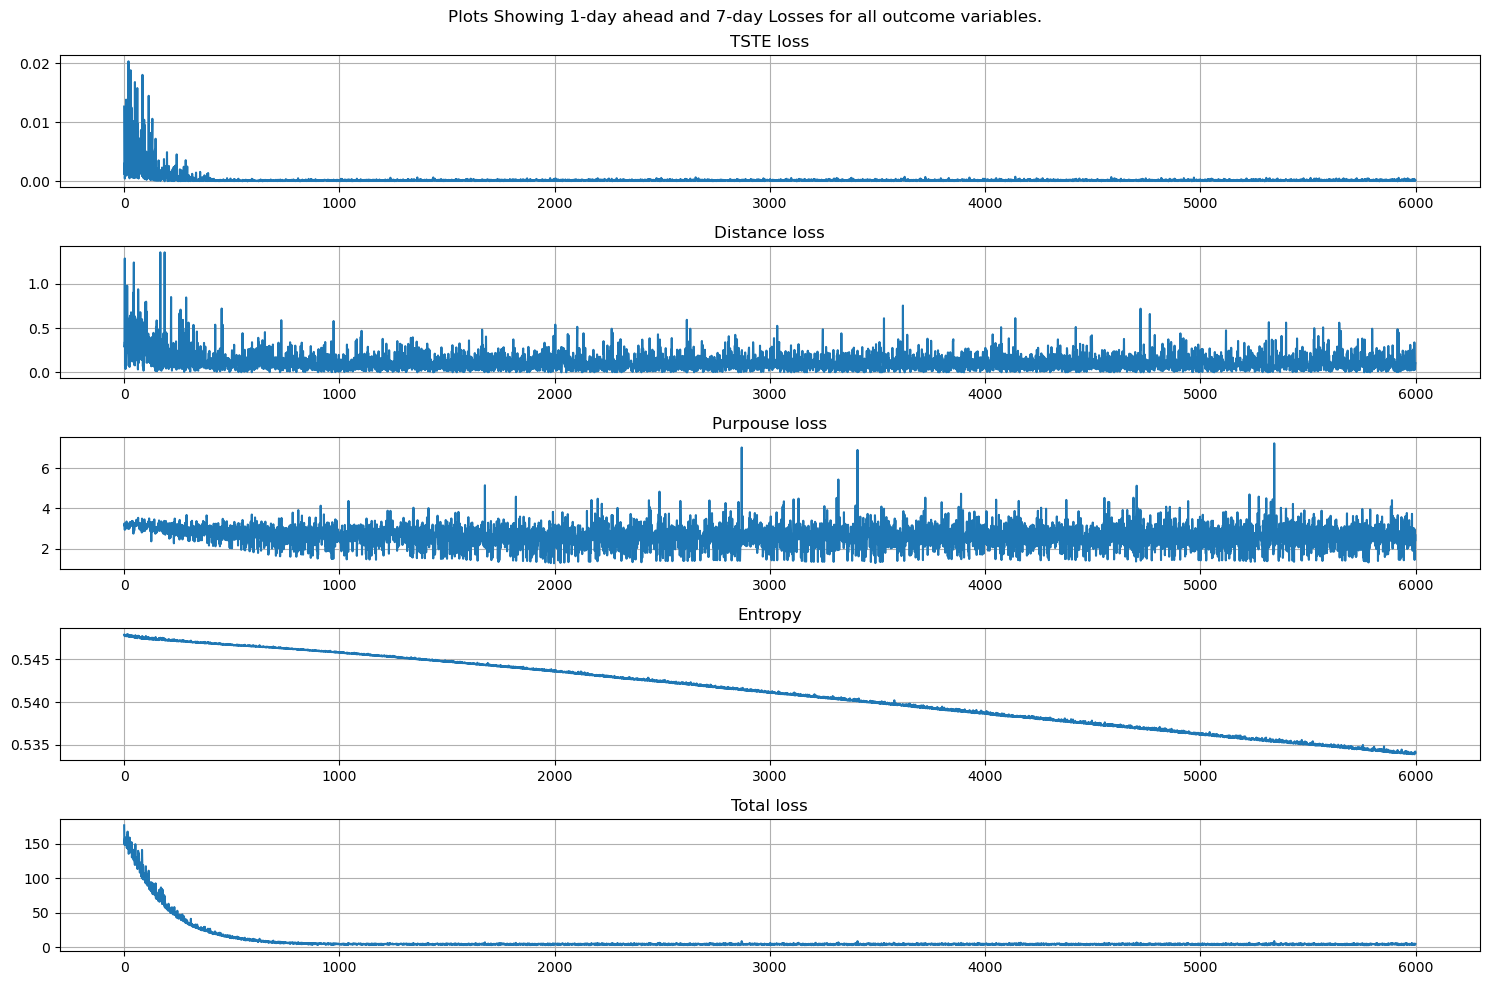

In [12]:
# Configure basic logging
logging.basicConfig(level=logging.INFO, force=True, format='%(levelname)s: %(message)s')


rnn_model = RNNmodel().to(device)

ce_loss = nn.CrossEntropyLoss(weight=ce_weighting, ignore_index=0).to(device)  #(y_hat, y)
mse_loss = nn.MSELoss(reduction="none").to(device)
bce_loss = nn.BCEWithLogitsLoss().to(device)

optimizer = torch.optim.Adam(rnn_model.parameters(), lr=0.0005)

epochs = 1
seq_length = 7
i_to_loop = 6000

c1_penalty_weight = 0.05
c2_penalty_weight = 0.2



ts_te_loss_weight = 1/800
purpouse_loss_weight = 1
distance_loss_weight = 50
istrip_loss_weight = 1

entropy_weight = 2
temperature = 5
tau = 2

make_travel_diaries = True
complete_travel_diaries = {}
complete_travel_diaries_dfs = []

total_losses = []
ts_te_losses= []
distance_losses = []
purpouse_losses = []
istrip_losses = []
entropy_evol = []


for epochi in range(epochs):

    for individual_i in range(i_to_loop):

        # Setting up prediction matrices for individual's travel week
        prediction_matrix_ts_te = []
        prediction_matrix_distance = []
        prediction_matrix_purpouse = []
        prediction_matrix_istrip = []
        masks_ts_te = []
        masks_other = []

        entropies = []

        # Truth values for that individual
        true_matrix_ts_te = y_ts_te[individual_i, :, 0, :].to(torch.float32)
        true_matrix_distance = y_distance[individual_i, :, 0, :].to(torch.float32)
        true_matrix_purpouse = y_purpouse[individual_i, :, 0, :].reshape(70).to(torch.long)
        true_matrix_istrip = y_istrip[individual_i, :, 0, :].to(torch.float32)

        logging.debug(f"Matrices of true values shape,ts_te, distance, purpouse, istrip")
        logging.debug(f"{true_matrix_ts_te.shape}")
        logging.debug(f"{true_matrix_distance.shape}")
        logging.debug(f"{true_matrix_purpouse.shape}")
        logging.debug(f"{true_matrix_istrip.shape}")

        travel_diary = X[individual_i, :, 0, :].unsqueeze(1).to(torch.float32)
        logging.debug(travel_diary.shape)

        # 7-day mask containing just the time-independent features
        X_features = X[individual_i, :, 0, 50:].unsqueeze(1).to(torch.float32)   # Features with masking and after masking
        ts_te_feature = torch.zeros(7,1,20).to(torch.float32).to(device)
        distance_feature = torch.zeros(7,1,10).to(torch.float32).to(device)
        purpouse_feature = torch.zeros(7,1,10*24).to(torch.float32).to(device)
        istrip_feature = torch.zeros(7,1,10).to(torch.float32).to(device)
        
        # Input matrix to feed into the model
        input_matrix = torch.concat([ts_te_feature, distance_feature, purpouse_feature, istrip_feature, X_features[:7,:,:]], dim=2)

        logging.debug(f"Shape of input matrix: {input_matrix.shape}")

        for t in range(0, seq_length):

            # Conditions of violation
    
            y_ts_te_pred_7, y_distance_pred_7, y_purpouse_pred_7, y_istrip_pred_7, is_trip_mask = rnn_model.forward(input_matrix)
            categorical_prediction7 = torch.argmax(y_purpouse_pred_7, dim=-1)

            # Reshaping
            y_purpouse_pred_7 = y_purpouse_pred_7.reshape(1,1,240)

            # Apply temperature-scaled softmax
            y_purpouse_softmax = F.softmax(y_purpouse_pred_7 / temperature, dim=-1)

            # Reshape back to match your input matrix (flattened)
            y_purpouse_softmax = y_purpouse_softmax.reshape(1, 1, 240)

            # Trying with the gumbel
            #y_purpouse_gumbel = F.gumbel_softmax(y_purpouse_pred_7, tau=tau, hard=True).reshape(1, 1, 240)

            # Calculating entropy across trip
            entropy_t = -(y_purpouse_softmax.reshape(10,24) * torch.log(y_purpouse_softmax + 1e-8).reshape(10,24)).sum(dim=1)
            entropies.append(entropy_t)

            if individual_i > i_to_loop-5:
                logging.info(y_purpouse_softmax.reshape(10,24))

            y_istrip_pred_7 = y_istrip_pred_7.reshape(1,1,-1)


            logging.debug("Predictions for {t}. Same order as always")
            logging.debug(y_ts_te_pred_7.shape)
            logging.debug(y_distance_pred_7.shape)
            logging.debug(y_purpouse_pred_7.shape)
            logging.debug(y_istrip_pred_7.shape)
            #logging.debug(y_mask_7.shape)
            logging.debug(f"Shape of this days X_features: {X_features[seq_length+t,:,:].unsqueeze(1).shape}")

            # New input row

            new_input_row = torch.concat([y_ts_te_pred_7, 
                                          y_distance_pred_7, 
                                          y_purpouse_softmax, 
                                          y_istrip_pred_7,
                                          X_features[seq_length+t,:,:].unsqueeze(1)], dim=2)

            # Appeding to input matrix

            # Slice off the first row of input_matrix

            input_matrix = input_matrix[1:,:,:]

            logging.debug(f"sliced of bottom row of input matrix, shape: {input_matrix.shape}")

            # Concatenate the redictions for t

            input_matrix = torch.cat([new_input_row, input_matrix], dim=0)

            logging.debug(f"New input matrix is input for next day: {input_matrix.shape}")

            logging.debug(input_matrix)

            # Appending to final prediction matrix
            prediction_matrix_ts_te.append(y_ts_te_pred_7.reshape(1,-1))
            prediction_matrix_distance.append(y_distance_pred_7.reshape(1,-1))
            prediction_matrix_purpouse.append(y_purpouse_pred_7.reshape(10,24))
            prediction_matrix_istrip.append(y_istrip_pred_7.reshape(1,-1))

            # Old mask code

            masks_ts_te.append(is_trip_mask.repeat_interleave(2).view(1,-1))
            masks_other.append(is_trip_mask.T)
        
            # Compute MSE and CE loss for one-day-ahead of the week

            #logging.debug(f"Original mask: {y_mask_7}")
            #logging.debug(f"interleaved_mask: {y_mask_7.repeat_interleave(2)}")


            # Compute MSE and CE loss for one-day-ahead of the week

        # Concatenating matrices

        # Making matrices of masks OLD CODE
        masks_ts_te = torch.cat(masks_ts_te, 0)
        masks_other = torch.cat(masks_other, 0)

        purpouse_mask = torch.clamp(true_matrix_purpouse.reshape(7,10),max=1)

        purpouse_mask_ts_te = purpouse_mask.repeat_interleave(2, dim=1)

        prediction_matrix_ts_te = torch.cat(prediction_matrix_ts_te, 0)
        prediction_matrix_distance = torch.cat(prediction_matrix_distance, 0)
        prediction_matrix_purpouse = torch.cat(prediction_matrix_purpouse, 0) 
        prediction_matrix_istrip = torch.cat(prediction_matrix_istrip, 0)

        if make_travel_diaries:
            purpouse_for_show = torch.argmax(prediction_matrix_purpouse, dim=1).reshape(7,10)

            matrix_for_show = torch.cat([prediction_matrix_ts_te * masks_ts_te, 
                                         prediction_matrix_distance * masks_other, 
                                         purpouse_for_show * masks_other, 
                                         masks_other], dim=1)
            
            complete_travel_diaries[individual_i] = matrix_for_show

            df = pd.DataFrame(complete_travel_diaries[individual_i].cpu().detach().numpy())
            df.iloc[:,:20] = df.iloc[:,:20].apply(lambda x: custom_numerical_scaler(x=x, x_min=0, x_max=60*24, inverse=True))
            df.iloc[:,20:30] = df.iloc[:,20:30].apply(lambda x: log_transformer(x, inverse=True))
            df["i_id"] = individual_i

            complete_travel_diaries_dfs.append(df)

        # Calculating loss with masks applied
        logging.debug(f"Matrices prediction/ true in usual order prior to adding to losses")

        logging.debug(f"Prediction of TSTE")
        logging.debug(prediction_matrix_ts_te*purpouse_mask_ts_te)
        logging.debug("")
        logging.debug(true_matrix_ts_te)

        ts_te_loss = mse_loss(prediction_matrix_ts_te,  true_matrix_ts_te)
        ts_te_loss = (ts_te_loss*purpouse_mask_ts_te).sum() / (purpouse_mask_ts_te.sum() + 1e-6)

        logging.debug(f"Prediction of Distance")
        logging.debug(prediction_matrix_distance*purpouse_mask)
        logging.debug("")
        logging.debug(true_matrix_distance)

        distance_loss = mse_loss(torch.log(1+prediction_matrix_distance),  torch.log(1+true_matrix_distance) )
        distance_loss = (distance_loss*purpouse_mask).sum() / (purpouse_mask.sum() + 1e-6)

        logging.debug(f"Prediction of Purpouse")
        logging.debug(purpouse_for_show)
        logging.debug("")
        logging.debug(true_matrix_purpouse)

        purpouse_loss = ce_loss(prediction_matrix_purpouse, true_matrix_purpouse)

        logging.debug(f"Prediction of Is trip")
        logging.debug(prediction_matrix_istrip)
        logging.debug("")
        logging.debug(true_matrix_istrip)

        istrip_loss = bce_loss(prediction_matrix_istrip, true_matrix_istrip)

        # RATIONALITY CONDITIONS

        ts_te_penalty_above_1 = torch.clamp(prediction_matrix_ts_te-1.0, min = 0).sum()

        # Encouraging entropy
        purpouse_entropy = torch.stack(entropies, dim=0).mean()

        #  c2_penalty_weight*ts_te_penalty_above_1

        total_loss = ts_te_loss*ts_te_loss_weight + distance_loss + purpouse_loss*purpouse_loss_weight + istrip_loss + c2_penalty_weight*ts_te_penalty_above_1 + entropy_weight*purpouse_entropy

        logging.debug(f"ts_te Loss requires grad? {ts_te_loss.requires_grad}")
        logging.debug(f"Distance Loss requires grad? {distance_loss.requires_grad}")
        logging.debug(f"Purpouse Loss requires grad? {purpouse_loss.requires_grad}")
        logging.debug(f"is trip Loss requires grad? {istrip_loss.requires_grad}")

        logging.info(f"epoch: {epochi} | individual: {individual_i+1}")
        #logging.info(f"ts_ts_loss: {ts_te_loss*ts_te_loss_weight:.2f}")
        #logging.info(f"distance_loss: {distance_loss:.2f}")
        #logging.info(f"purpouse_loss: {purpouse_loss:.2f}")
        #logging.info(f"istrip_loss: {istrip_loss:.2f}")
        logging.info(f"total_loss: {total_loss:.2f}")

        # Appending losses
        total_losses.append(total_loss.cpu().detach().numpy())
        ts_te_losses.append(  (ts_te_loss*ts_te_loss_weight).cpu().detach().numpy())
        distance_losses.append(distance_loss.cpu().detach().numpy())
        purpouse_losses.append((purpouse_loss*purpouse_loss_weight).cpu().detach().numpy())
        istrip_losses.append(istrip_loss.cpu().detach().numpy())
        entropy_evol.append(purpouse_entropy.cpu().detach().numpy())

        # BACKPROP
        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()



plt.figure(figsize=(15, 10))

plt.suptitle("Plots Showing 1-day ahead and 7-day Losses for all outcome variables.")

x_vals = np.arange(i_to_loop)  # Ensure correct x-axis scaling




plt.subplot(5,1,1)
plt.title("TSTE loss")
plt.plot(x_vals, ts_te_losses, label="ts_te")
plt.grid()

plt.subplot(5,1,2)
plt.title("Distance loss")
plt.plot(x_vals, distance_losses, label="distance")
plt.grid()

plt.subplot(5,1,3)
plt.title("Purpouse loss")
plt.plot(x_vals, purpouse_losses, label="purpouse")
plt.grid()

plt.subplot(5,1,4)
plt.title("Entropy")
plt.plot(x_vals, entropy_evol, label="entropy")
plt.grid()


plt.subplot(5,1,5)
plt.title("Total loss")
plt.plot(x_vals, total_losses)

plt.grid()

plt.tight_layout()



plt.show()
        

In [13]:
full_df = pd.concat(complete_travel_diaries_dfs)

In [20]:
full_df.iloc[41000:,10:20]

,10,11,12,13,14,15,16,17,18,19
1,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.00000,0.000000
2,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.00000,0.000000
3,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.00000,0.000000
4,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.00000,0.000000
5,0.0,0.0,962.701233,1005.782104,0.0,0.0,0.0,0.0,0.00000,0.000000
...,...,...,...,...,...,...,...,...,...,...
2,0.0,0.0,994.888245,1039.684082,0.0,0.0,0.0,0.0,1301.02478,1341.964233
3,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.00000,0.000000
4,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.00000,0.000000
5,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.00000,0.000000


In [21]:
y_distance.mean()

tensor(0.3539, device='cuda:0')

In [55]:
purpouse_for_show

tensor([[1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 0, 0, 0, 0, 0, 0, 0, 0]], device='cuda:0')

In [22]:
full_df.to_csv("/home/trapfishscott/Cambridge24.25/D200_ML_econ/ProblemSets/Project/data/complete_trav_diaries.csv", index=False)

In [ ]:
### INDIVIDUAL PARTS ####

# RATIONALITY CONDITIONS

ts_te_penalty_above_11 = torch.clamp(y_ts_te_pred_1-1, min = 0).sum()
ts_te_penalty_above_17 = torch.clamp(y_ts_te_pred_7-1, min = 0).sum()

ts_te_delta1 = y_ts_te_pred_1[:,:,1::2] - y_ts_te_pred_1[:,:,0::2]
ts_te_delta7 = y_ts_te_pred_7[:,:,1::2] - y_ts_te_pred_7[:,:,0::2]

max_distance1 = ts_te_delta1 * normalised_mp_minute
max_distance7 = ts_te_delta7 * normalised_mp_minute

max_distance_penalty1 = torch.clamp(y_distance_pred_1 - max_distance1, min=0).sum()
min_distance_penalty1 = torch.clamp(-y_distance_pred_1, min=0).sum()
total_distance_penalty1 = max_distance_penalty1 + max_distance_penalty1

max_distance_penalty7 = torch.clamp(y_distance_pred_7 - max_distance7, min=0).sum()
min_distance_penalty7 = torch.clamp(-y_distance_pred_7, min=0).sum()
total_distance_penalty7 = max_distance_penalty7 + max_distance_penalty7